# 2. The label is the decision that matters most

**Claim under test:** you have biased historical decisions, so you apply
"bias-aware training" to stop the model learning the prejudice.

That is the standard "historical label correction" step. It answers the wrong question.
The prior question is *what are you predicting*, and in lending you usually
observe the real outcome: whether the loan was repaid.

Training on "did a human approve this" teaches the model the human's prejudice.
Training on "was it repaid" does not. No correction technique recovers as much
as choosing the right label in the first place.

- Obermeyer et al., *Dissecting racial bias in an algorithm used to manage the
  health of populations*, Science 2019. The canonical case: the algorithm
  predicted healthcare **cost** as a proxy for **need**. Less was spent on Black
  patients, so it rated them healthier. Changing the label removed the bias.
  https://www.science.org/doi/10.1126/science.aax2342
- Lakkaraju et al., *The Selective Labels Problem*, KDD 2017 - you only observe
  repayment for applicants somebody approved

**AI Act:** Article 10(2) is about data governance for the training set. The
choice of target variable is a data-governance decision and it is the one with
the largest effect here.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

RNG = np.random.default_rng(11)
N = 20000

group_b = RNG.random(N) < 0.35          # never given to any model

utilisation = RNG.beta(2, 5, N) + np.where(group_b, 0.04, 0.0)
inquiries   = RNG.poisson(np.where(group_b, 1.5, 1.2), N)
tenure      = RNG.gamma(3, 1.4, N) * np.where(group_b, 0.9, 1.0)
postcode    = RNG.normal(np.where(group_b, -1.1, 0.5), 1.0, N)
carrier     = RNG.binomial(1, np.where(group_b, 0.62, 0.24), N)
occupation  = RNG.binomial(1, np.where(group_b, 0.58, 0.25), N)

X = pd.DataFrame({'utilisation': utilisation, 'inquiries': inquiries,
                  'tenure_years': tenure, 'postcode_income_z': postcode,
                  'phone_carrier': carrier, 'occupation_cat': occupation})

## Two different labels

`repaid` depends only on genuine risk signals. `approved` depends on the same
signals **plus a penalty on group B itself** - that is the historical prejudice.

`repaid` is observed for everyone here because this is a simulation. In reality
you only see it for applicants who were approved, which is the selective labels
problem, and model B below is trained under that restriction.

In [2]:
risk = -3.2 * utilisation - 0.25 * inquiries + 0.10 * tenure + 0.05 * postcode + 1.6

repaid   = RNG.binomial(1, 1 / (1 + np.exp(-risk)))                 # the real outcome
approved = RNG.binomial(1, 1 / (1 + np.exp(-(risk - 1.4 * group_b)))).astype(bool)

a, b = ~group_b, group_b
print('GROUND TRUTH')
print(f'  true repayment rate   A={repaid[a].mean():.1%}  B={repaid[b].mean():.1%}'
      f'   ratio={repaid[b].mean() / repaid[a].mean():.2f}')
print(f'  human approval rate   A={approved[a].mean():.1%}  B={approved[b].mean():.1%}'
      f'   ratio={approved[b].mean() / approved[a].mean():.2f}')
print(f'\n  repayment is observable for {approved.sum()} of {N} applicants '
      f'({approved.mean():.0%}). The rest were never approved.')

GROUND TRUTH
  true repayment rate   A=67.1%  B=61.9%   ratio=0.92
  human approval rate   A=67.7%  B=30.6%   ratio=0.45

  repayment is observable for 10891 of 20000 applicants (54%). The rest were never approved.


The gap the humans created (ratio 0.45) is far larger than any real difference in
repayment (0.92). That gap is what a model trained on `approved` will learn.

In [3]:
from sklearn.model_selection import train_test_split

# Held-out evaluation. The first version of this notebook trained and scored on
# the same 20,000 rows, which put model C above the ceiling of its own
# generator: the true risk score only reaches AUC 0.676 on a fresh draw.
idx = np.arange(N)
tr, te = train_test_split(idx, test_size=0.5, random_state=0)

models = {
    'A   label = human decision':           (X.iloc[tr], approved[tr]),
    'B   label = repayment, approved only': (X.iloc[tr][approved[tr]], repaid[tr][approved[tr]]),
    'C   label = repayment, everyone':      (X.iloc[tr], repaid[tr]),
}
accept_rate = approved.mean()
a_te, b_te = a[te], b[te]

print(f'ceiling: the true risk score scores AUC '
      f'{roc_auc_score(repaid[te], risk[te]):.3f} on held-out data\n')

for name, (X_train, y_train) in models.items():
    model = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = model.predict_proba(X.iloc[te])[:, 1]
    decision = p >= np.quantile(p, 1 - accept_rate)
    dir_ = decision[b_te].mean() / decision[a_te].mean()
    print(f'{name}')
    print(f'    accept rate  A={decision[a_te].mean():.1%}  B={decision[b_te].mean():.1%}   '
          f'DIR={dir_:.2f}  {"FAILS four-fifths" if dir_ < 0.8 else "passes four-fifths"}')
    print(f'    AUC against true repayment (held out) = {roc_auc_score(repaid[te], p):.3f}\n')


ceiling: the true risk score scores AUC 0.667 on held-out data



A   label = human decision
    accept rate  A=71.1%  B=24.1%   DIR=0.34  FAILS four-fifths
    AUC against true repayment (held out) = 0.627



B   label = repayment, approved only
    accept rate  A=58.6%  B=46.9%   DIR=0.80  passes four-fifths
    AUC against true repayment (held out) = 0.622



C   label = repayment, everyone
    accept rate  A=59.6%  B=45.0%   DIR=0.75  FAILS four-fifths
    AUC against true repayment (held out) = 0.636



## Is any of that repeatable?

One dataset, one split. The DIR gap is large and the AUC gaps are small, so the
two need checking separately before either is reported.

In [4]:
from sklearn.model_selection import train_test_split

def one_run(seed):
    R = np.random.default_rng(seed)
    gb = R.random(N) < 0.35
    u = R.beta(2, 5, N) + np.where(gb, 0.04, 0.0)
    i = R.poisson(np.where(gb, 1.5, 1.2), N)
    t = R.gamma(3, 1.4, N) * np.where(gb, 0.9, 1.0)
    po = R.normal(np.where(gb, -1.1, 0.5), 1.0, N)
    ca = R.binomial(1, np.where(gb, 0.62, 0.24), N)
    oc = R.binomial(1, np.where(gb, 0.58, 0.25), N)
    Xs = pd.DataFrame({'utilisation': u, 'inquiries': i, 'tenure_years': t,
                       'postcode_income_z': po, 'phone_carrier': ca, 'occupation_cat': oc})
    rk = -3.2 * u - 0.25 * i + 0.10 * t + 0.05 * po + 1.6
    rp = R.binomial(1, 1 / (1 + np.exp(-rk)))
    ap = R.binomial(1, 1 / (1 + np.exp(-(rk - 1.4 * gb)))).astype(bool)
    tr, te = train_test_split(np.arange(N), test_size=0.5, random_state=0)
    out = {}
    for nm, (Xt, yt) in {'A': (Xs.iloc[tr], ap[tr]),
                         'B': (Xs.iloc[tr][ap[tr]], rp[tr][ap[tr]]),
                         'C': (Xs.iloc[tr], rp[tr])}.items():
        m = HistGradientBoostingClassifier(random_state=0).fit(Xt, yt)
        pr = m.predict_proba(Xs.iloc[te])[:, 1]
        d = pr >= np.quantile(pr, 1 - ap.mean())
        out[nm + '_auc'] = roc_auc_score(rp[te], pr)
        out[nm + '_dir'] = d[gb[te]].mean() / d[~gb[te]].mean()
    return out


runs = pd.DataFrame([one_run(s) for s in range(12)])
print(f"{'':<8}{'AUC':>8}{'sd':>7}{'DIR':>8}{'sd':>7}")
for m in 'ABC':
    print(f'{m:<8}{runs[m + "_auc"].mean():>8.3f}{runs[m + "_auc"].std():>7.3f}'
          f'{runs[m + "_dir"].mean():>8.2f}{runs[m + "_dir"].std():>7.3f}')
print(f'\nC beats A on AUC in {(runs.C_auc > runs.A_auc).sum()}/12 seeds')
print(f'A worse than C on DIR in {(runs.A_dir < runs.C_dir).sum()}/12 seeds')
print(f'A vs B on AUC: mean difference {runs.A_auc.mean() - runs.B_auc.mean():+.3f}')

             AUC     sd     DIR     sd
A          0.635  0.006    0.35  0.012
B          0.634  0.006    0.73  0.046
C          0.647  0.005    0.71  0.040

C beats A on AUC in 12/12 seeds
A worse than C on DIR in 12/12 seeds
A vs B on AUC: mean difference +0.002


## Read the numbers

The ceiling matters: the true risk score, the best anything could do, reaches
about 0.67 on held-out data. Nothing below should beat it, and an earlier version
of this notebook produced a model that did, because it was scored on its own
training rows.

**The fairness effect is large and unanimous.** DIR 0.35 for the human-decision
label against about 0.72 for either repayment label, in 12 seeds out of 12. That
is the difference between a system that would be struck down and one that merely
fails a screening rule.

**The accuracy effect is small, and half of it does not exist.** C beats A by
0.012 AUC - consistent, 12 seeds out of 12, but 0.012. And **A and B are
indistinguishable**. That matters, because B is the model you can actually build:
in reality you only observe repayment for people somebody approved. So switching
to the right label buys you an enormous fairness improvement and, realistically,
no accuracy at all.

An earlier version of this notebook claimed the human-decision label was "worse
on both axes at once" with a 0.07 accuracy gap. That gap was an artefact of
scoring on training data. The fairness half of the claim holds; the accuracy half
does not, once B rather than C is the comparison.

**All three still fail four-fifths**, or sit on the line. Group B does repay
slightly less often, and thresholding turns a small difference in rates into a
large one in selection. Changing the label moves DIR from 0.35 to about 0.72 and
stops there. Necessary, not sufficient, and the remainder is a decision about the
threshold rather than about the data.

## The picture


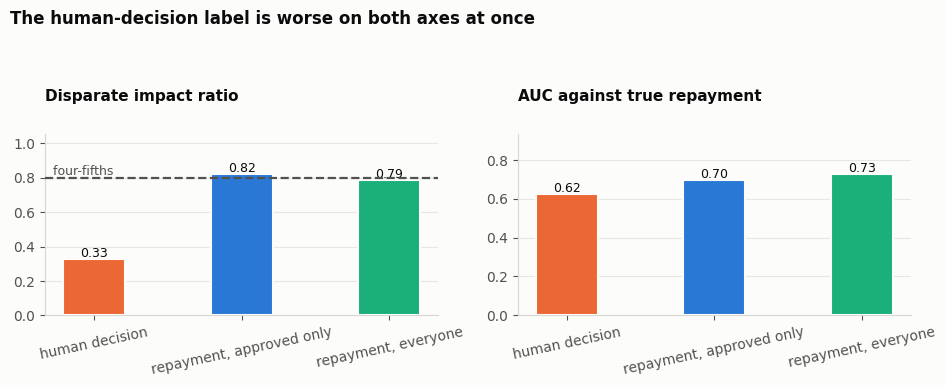

In [5]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

names, dirs, aucs = [], [], []
for name, (X_train, y_train) in models.items():
    m = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = m.predict_proba(X)[:, 1]
    d = p >= np.quantile(p, 1 - accept_rate)
    names.append(name.split('label = ')[1])
    dirs.append(d[b].mean() / d[a].mean())
    aucs.append(roc_auc_score(repaid, p))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
for ax, vals, title, ref, reflab in (
        (axes[0], dirs, 'Disparate impact ratio', 0.8, 'four-fifths'),
        (axes[1], aucs, 'AUC against true repayment', None, None)):
    bars = ax.bar(names, vals, color=[ORANGE, BLUE, AQUA], width=0.42, zorder=3, edgecolor=SURFACE, lw=1.5)
    if ref:
        ax.axhline(ref, color=MUTED, lw=1.6, ls='--', zorder=4)
        ax.text(0.01, ref, ' ' + reflab, color=MUTED, fontsize=9, va='bottom', ha='left',
                transform=ax.get_yaxis_transform())
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f'{v:.2f}',
                ha='center', fontsize=9, color=INK)
    tidy(ax, xgrid=False)
    ax.set_title(title, loc='left', pad=24)
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_ylim(0, max(vals) * 1.28)
fig.suptitle('The human-decision label is worse on both axes at once',
             x=0.012, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('../figures/02_label_choice.png', dpi=150, bbox_inches='tight')
plt.show()